<img src="./ccsf.png" alt="CCSF Logo" width=200px style="margin:0px -5px">

# Lab -1: Beyond `datascience`

---

## Learning Objectives

1. Reflect on the design of MATH 108.
2. Navigate tabular data using the `pandas` library.
3. Create visualizations using the `matplotlib` library.
6. Explore regression using the `sklearn` and `scipy` libraries.
7. Explore classification using the `sklearn` library.

---

## Configure the Notebook

### Task 00 📍

<!-- BEGIN QUESTION -->

Run the following code cell to set up this notebook for this activity.

In [1]:
import numpy as np
import os
import otter

try:
    notebook_name = "labn1.ipynb"
    session_name = os.getenv('JPY_SESSION_NAME')
    
    if session_name:
        notebook_name = os.path.basename(session_name)
        print(f"Detected notebook name from environment: {notebook_name}")
    else:
        print("Environment variable 'JPY_SESSION_NAME' not found. Using default notebook name: gla01.ipynb")
        
    grader = otter.Notebook(notebook_name)
    print(f"The Otter grader has been initialized with {notebook_name}.")
except Exception as e:
    raise RuntimeError(f"Failed to initialize Otter grader: {e}") from e

Detected notebook name from environment: labn1.ipynb
The Otter grader has been initialized with labn1.ipynb.


<!-- END QUESTION -->

---

## MATH 108 Design

- MATH 108 was adapted from UC Berkeley's [**DATA 8** course](https://www.data8.org/)
- Data 8 was designed to introduce first-year students to foundational topics in data science
    - It assumed students had only a High School–level background in math (basic algebra and some statistics)
    - It did **not** assume any prior programming experience
- A central goal of the course was for students to **build their own versions** of common data analysis tools:
    - Hypothesis tests, confidence intervals, regression models, k-nearest neighbors classifiers, and more
- These tools typically have standard library implementations, but the emphasis in MATH 108 was on **understanding by constructing**
- The `datascience` library supported this approach by simplifying the programming interface, making it easier for beginners to focus on core concepts while learning to code
- For this activity, you will complete a few past guided learning activities using some more standard methods and avoid using the `datascience` library.

---

## Common Libraries

---

### `pandas`

- In MATH 108, you worked with tabular data using the `Table` data type from the `datascience` library
- A more common and widely used alternative is the [`DataFrame`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html) from the `pandas` library
- While a `Table` is great for teaching and simplicity, a `DataFrame` offers more powerful and flexible tools for real-world data analysis
- The first notable difference for you is that a `DataFrame` shows the row index number by default
- Run the following code to import `pandas` using the standard alias `pd`

In [2]:
import pandas as pd

#### Comparing Syntax

- View the [official User Guide for `pandas`](https://pandas.pydata.org/docs/user_guide/index.html) to see what features it has.
- Here is a brief comparison between a `DataFrame` and a `Table`:
    | Concept         | `datascience.Table`                  | `pandas.DataFrame`              |
    |----------------|---------------------------------------|----------------------------------|
    | Rows & columns | ✅ Yes                                 | ✅ Yes                            |
    | Column access  | `tbl.column('label')` → NumPy array   | `df['label']` → Series           |
    | Row access     | `tbl.row(index)`                      | `df.iloc[index]`                 |
    | Select columns | `tbl.select('col1', 'col2')`          | `df[['col1', 'col2']]`           |
    | Filter rows    | `tbl.where('col', condition)`         | `df[df['col'] > value]`          |
    | Add columns    | `tbl.with_column('label', values)`    | `df['label'] = values`           |
    | Summary functions  | `tbl.group(...)`, `tbl.apply(...)`    | `df.groupby(...)`, `df.apply(...)` |
    | Plotting       | `tbl.plot(...)`                       | `matplotlib` or `df.plot(...)`   |
- If you haven't done so already, go through the notebook provided by UC Berkeley on [Translating from `datascience` to `pandas`](https://colab.research.google.com/drive/1zYnagJUnxZWI2BSrpRdnyG7Knu3Tkada?usp=sharing) that was linked in the MATH 108 Conclusion lecture.

---

### `matplotlib`

- One of the most fundamental visualization libraries in Python is `matplotlib`
- Matplotlib is renowned for its **customizability**, though it can be less intuitive for beginners.
- The `datascience` library is built on top of Matplotlib
- You might have noticed that MATH 108 instructors often use Matplotlib directly to add custom touches like titles, updated axes, colors, and more
- Run the following code to import `matplotlib` using the standard alias `plt` and apply the same styling used in MATH 108

In [3]:
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

View the [official User Guide for `matplotlib`](https://matplotlib.org/stable/users/index) to see what features it has.

---

### `scikit.learn`

- The two general types of machine learning problems introduced in MATH 108 are:
  - **Regression**: Predicting numerical outcomes from numerical features.
  - **Classification**: Predicting categorical outcomes from numerical features.
- [**scikit-learn**](https://scikit-learn.org) is a widely used Python library for implementing machine learning models.
  - It includes tools for linear and nonlinear regression, k-nearest neighbors (kNN) classification, and more.
  - It also provides functions to **standardize data**, **evaluate models**, and **split data into training and testing sets**.
- Use the following line to import `scikit-learn` using the standard alias `sk`:

In [4]:
import sklearn as sk

---

### `scipy`

- [**SciPy**](https://scipy.org) is a core library for scientific computing in Python, built on top of NumPy.
  - It includes tools for **curve fitting**, **optimization**, **integration**, **statistics**, and more.
  - The `scipy.optimize.curve_fit` function allows you to fit **custom mathematical models** to data.
- Run the following line to import `scipy` and give the standard alias of `sp`:

In [5]:
import scipy as sp

---

## Regression

---

### Michaelis–Menten Kinetics

<a href="https://en.wikipedia.org/wiki/Michaelis%E2%80%93Menten_kinetics" target="_blank"><img src="./MM-curve.jpg" width=400px alt="Curve of the Michaelis–Menten equation labelled in accordance with IUBMB recommendations"></a>

From <a href="https://en.wikipedia.org/wiki/Michaelis%E2%80%93Menten_kinetics" target="_blank">Wikipedia</a>:

> In biochemistry, Michaelis–Menten kinetics, named after Leonor Michaelis and Maud Menten, is the simplest case of enzyme kinetics, applied to enzyme-catalysed reactions involving the transformation of one substrate into one product.

---

### Biochemistry Basics

- **Enzyme**: A protein that speeds up chemical reactions in the body.
- **Substrate**: The molecule that the enzyme acts on (like a key in a lock).
- **Enzyme + substrate → product**: The reaction rate depends on substrate amount.
- **Saturation point**: When all enzymes are busy, adding more substrate won't increase speed.

---

### The Data

The file [`puromycin.csv`](https://www.rdocumentation.org/packages/datasets/versions/3.6.2/topics/Puromycin) contains 23 rows and 3 columns of the reaction velocity versus substrate concentration in an enzymatic reaction involving untreated cells or cells treated with [Puromycin](https://en.wikipedia.org/wiki/Puromycin), an inhibitor that slows down enzymatic reactions.

---

### Task 01 📍

Assign the `puromycin.csv` to the `DataFrame` called `puromycin`. The `DataFrame` should contain only the untreated data and the following columns:

- `'Concentration'`: a numeric vector of substrate concentrations (ppm)
- `'Reaction Rate'`: a numeric vector of instantaneous reaction rates (counts/min/min)

**Conversion Notes**:
- `pd.read_csv()` loads a `CSV` into a `DataFrame`, similar to `Table.read_table(...)`.
- `tbl = tbl[tbl['column_label'] == 'value']]` filters rows of a `DataFrame` like `tbl.where('column_label', 'value')`.
    - Instead of `.where()`, you use Boolean indexing with a condition inside `[]`.
- `.drop(columns=...)` removes a column, similar to `tbl.drop(...)`.
- `.rename(columns={...})` changes column names, like `tbl.relabeled(...)`.
    - The `{...}` is a dictionary, containing `{key:value}` pairs.
    - In this case, the pairs would be `{old_label: new_label, ...}`
- `.reset_index(drop=True)` resets the row index (especially after filtering).

In [6]:
""" # BEGIN PROMPT
puromycin = ...
"""; # END PROMPT
# BEGIN SOLUTION NO PROMPT
puromycin = pd.read_csv('puromycin.csv')
puromycin = puromycin[puromycin['state'] == 'untreated']
puromycin = puromycin.drop(columns='state')
puromycin = puromycin.rename(columns={'conc': 'Concentration', 'rate': 'Reaction Rate'})
puromycin = puromycin.reset_index(drop=True)
# END SOLUTION
puromycin

,Concentration,Reaction Rate
0,0.02,67
1,0.02,51
2,0.06,84
3,0.06,86
4,0.11,98
5,0.11,115
6,0.22,131
7,0.22,124
8,0.56,144
9,0.56,158


In [ ]:
grader.check("task_01")

---

### Task 02 📍🔎

<!-- BEGIN QUESTION -->

Visualize the relationship between the substrate concentrations and reaction rates, where the concentrations are the explanatory variable.

**Conversion Notes**:
- `df['column']` produces a `Series` (like an array), similar to `tbl.column('column')`.
- `plt.scatter(x, y)` creates a scatter plot like `tbl.scatter(...)` in `datascience`.
- You can add a title and update x and y labels using `plt.title`, `plt.xlabel`, and `plt.ylabel`.
- `plt.show()` displays the plot.

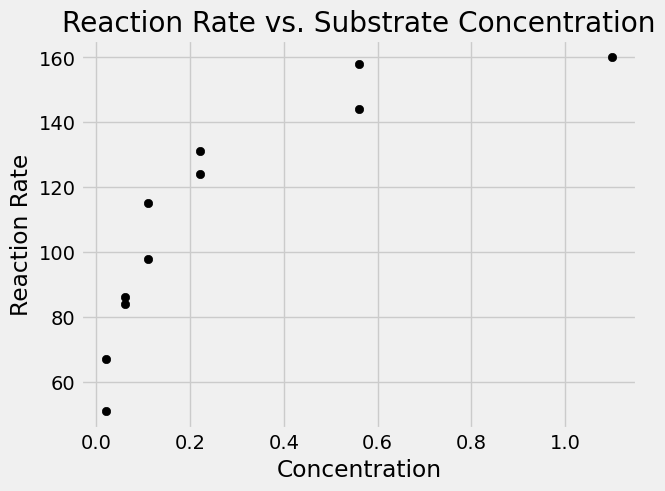

In [8]:
""" # BEGIN PROMPT
...
"""; # END PROMPT
# BEGIN SOLUTION NO PROMPT
concentrations = puromycin['Concentration']
reaction_rates = puromycin['Reaction Rate']
plt.scatter(concentrations, reaction_rates, color='black')
plt.title('Reaction Rate vs. Substrate Concentration')
plt.xlabel('Concentration')
plt.ylabel('Reaction Rate')
plt.show()
# END SOLUTION

<!-- END QUESTION -->

---

### Task 03 📍🔎

<!-- BEGIN QUESTION -->

Fit a linear model to the data in `puromycin`, and use the model to create an array of predicted reaction rates (`y_pred`) based on the model and given concentration amounts.

**Notes**:
- Determining the slope and intercept that minimize MSE is part of fitting a linear model to a data set.
- `sklearn` has a tool `LinearRegression` from the `linear_model` sub-module to help with that.
    - Use `from sklearn.linear_model import LinearRegression`
    - `LinearRegression()` creates an empty linear regression model (e.g. `linear_model`) object-like `fit_line(...)` in MATH 108.
- `X` is a `DataFrame` with the predictor(s)
    - double brackets `[[]]` keep it 2-dimensional (as required by `sklearn`).
    - Like: `tbl.select('column')`
- `y` is a `Series` (1D)
    - This is the variable we're trying to predict.
    - Like: `tbl.column('column')`
- `linear_model.fit(X, y)` determines and stores the correlation coefficient, slope, intercept, etc. associated with the regression line for the provided data.
- After fitting the model, you can use it to predict outcomes (`linear_model.predict(X)`) for given inputs (`X`).
    - This returns an array of predicted `y` values based on the learned regression line.

In [9]:
""" # BEGIN PROMPT
...
X = ...
y = ...
linear_model = ...
...
y_pred = ...
y_pred
"""; # END PROMPT
# BEGIN SOLUTION NO PROMPT
from sklearn.linear_model import LinearRegression
X = puromycin[['Concentration']]
y = puromycin['Reaction Rate']
linear_model = LinearRegression()
linear_model.fit(X, y)
y_pred = linear_model.predict(X)
y_pred
# END SOLUTION

array([ 87.82434243,  87.82434243,  91.39784929,  91.39784929,
        95.86473286,  95.86473286, 105.69187671, 105.69187671,
       136.06668497, 136.06668497, 184.3090275 ])

<!-- END QUESTION -->

---

### Task 04 📍🔎

<!-- BEGIN QUESTION -->

Add the fit line to the scatter plot. Include a legend that provides a label for the scatterplot and regression line.

**Notes**:
- `plt.plot(x, y)` creates a **line plot**, similar to `tbl.plot(...)` in the `datascience` library.
- To **label a line** in the plot, use the `label='Name'` parameter inside `plt.plot(...)`.
- `plt.legend()` adds a **legend box** to the plot, displaying the label(s) you’ve specified.
    - This is especially useful when comparing multiple lines or datasets in one plot.

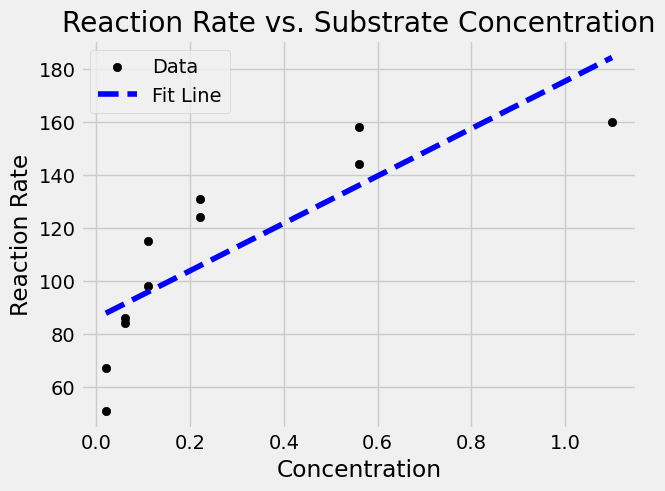

In [10]:
""" # BEGIN PROMPT
...
"""; # END PROMPT
# BEGIN SOLUTION NO PROMPT
plt.scatter(X, y, color='black', label='Data')
plt.plot(X, y_pred, color='blue', linestyle='--', label='Fit Line')
plt.title('Reaction Rate vs. Substrate Concentration')
plt.xlabel('Concentration')
plt.ylabel('Reaction Rate')
plt.legend()
plt.show()
# END SOLUTION

<!-- END QUESTION -->

---

### Task 05 📍🔎

<!-- BEGIN QUESTION -->

Create a residual plot for this regression model. Include a horizontal line at $y=0$.

**Notes**:
- `plt.axhline(y=...)` creates a horizontal line plot vertical posted at the provided `y` value.

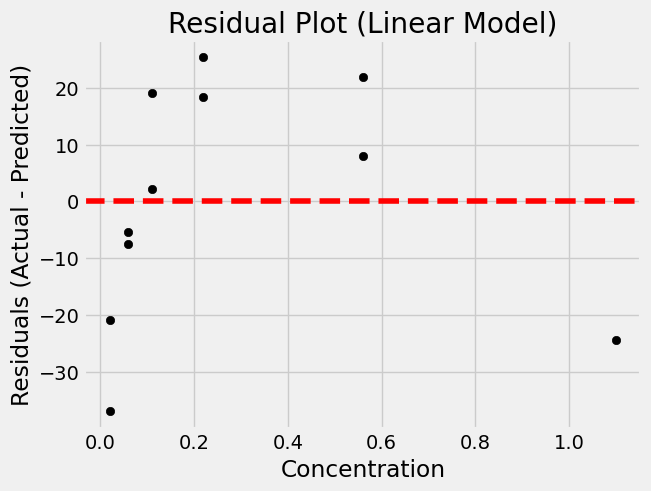

In [11]:
""" # BEGIN PROMPT
residuals = ...

...
"""; # END PROMPT
# BEGIN SOLUTION NO PROMPT
residuals = y - y_pred

plt.scatter(X, residuals, color='black')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot (Linear Model)')
plt.xlabel('Concentration')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()
# END SOLUTION

<!-- END QUESTION -->

---

### Task 06 📍🔎

<!-- BEGIN QUESTION -->

Calculate the mean squared error for the best fit linear model.

**Notes**:
- There is an MSE function in `sklearn.metrics`
- Use `from sklearn.metrics import mean_squared_error`

In [12]:
""" # BEGIN PROMPT
...

mse = ...
print("Mean Squared Error:", mse)
"""; # END PROMPT
# BEGIN SOLUTION NO PROMPT
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y, y_pred)
print("Linear Mean Squared Error:", mse)
# END SOLUTION

Linear Mean Squared Error: 395.89939054374


<!-- END QUESTION -->

---

### Task 07 📍🔎

<!-- BEGIN QUESTION -->

Next, fit the model defined by the Michaelis-Menten Function, and make predictions `y_pred_2` from the provided concentrations in `puromycin`.

**Notes:**
- A general curve can be fit to data using the `scipy` function `curve_fit`.
    - Use  `from scipy.optimize import curve_fit` to access this function.
    - You should provide `curve_fit` with the function, the $X$-data, and the $y$-data for it to fit the function to the data.
    - `curve_fit` returns a few items, the first is an array of parameters for the given function that minimize MSE.
- `df['column_label'].values` provides the values of the `Series` as a NumPy array.

In [13]:
""" # BEGIN PROMPT
...

def michaelis_menten(S, Vmax, Km):
    return ...

X_vals = ...
y_vals = ...

params, __ = ... # __ is used to "catch" the rest of the output
Vmax, Km = params # expand the params array

y_pred_2 = ...
"""; # END PROMPT
# BEGIN SOLUTION NO PROMPT
from scipy.optimize import curve_fit

def michaelis_menten(S, Vmax, Km):
    return (Vmax * S) / (Km + S)

X_vals = puromycin['Concentration'].values
y_vals = puromycin['Reaction Rate'].values

params, __ = curve_fit(michaelis_menten, X_vals, y_vals) 
Vmax, Km = params

y_pred_2 = michaelis_menten(X_vals, Vmax, Km)
# END SOLUTION
y_pred_2

array([ 47.34449633,  47.34449633,  89.28584185,  89.28584185,
       111.79391689, 111.79391689, 131.71658333, 131.71658333,
       147.697155  , 147.697155  , 153.61736346])

<!-- END QUESTION -->

---

### Task 08 📍🔎

<!-- BEGIN QUESTION -->

Visualize the fit line defined by the Michaelis–Menten formula on the scatterplot relating reaction rate vs. substrate concentration.

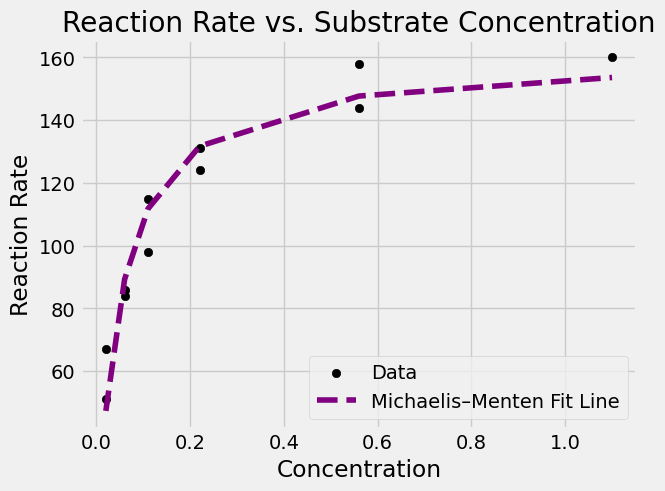

In [14]:
""" # BEGIN PROMPT
...
"""; # END PROMPT
# BEGIN SOLUTION NO PROMPT
plt.scatter(X, y, color='black', label='Data')
plt.plot(X, y_pred_2, color='purple', linestyle='--', label='Michaelis–Menten Fit Line')
plt.xlabel('Concentration')
plt.ylabel('Reaction Rate')
plt.title('Reaction Rate vs. Substrate Concentration')
plt.legend()
plt.show()
# END SOLUTION

<!-- END QUESTION -->

---

### Task 09 📍🔎

<!-- BEGIN QUESTION -->

Create a residual plot for this model and calculate the MSE value for this model (`mse_2`).

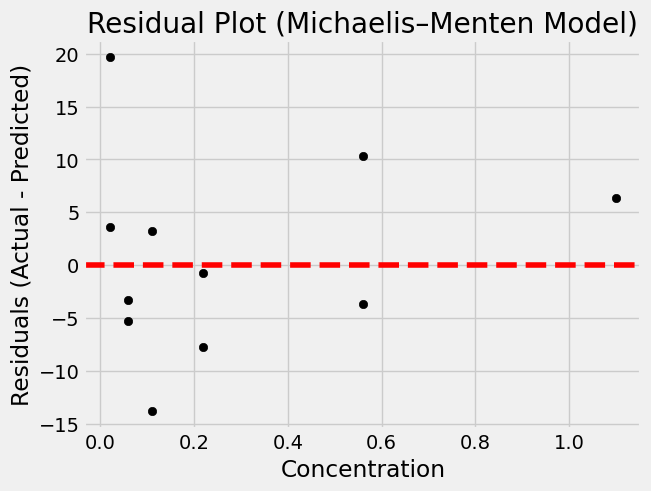

Michaelis–Menten Mean Squared Error: 78.14584489735633


In [15]:
""" # BEGIN PROMPT
...
"""; # END PROMPT
# BEGIN SOLUTION NO PROMPT
residuals_2 = y - y_pred_2

plt.scatter(X, residuals_2, color='black')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot (Michaelis–Menten Model)')
plt.xlabel('Concentration')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()

mse_2 = mean_squared_error(y, y_pred_2)
print("Michaelis–Menten Mean Squared Error:", mse_2)
# END SOLUTION

<!-- END QUESTION -->

---

## Classification

---

### Gallstone Disease

<a href="https://en.wikipedia.org/wiki/Gallstone" target="_blank"><img src="./gallstones.png" width=400px alt="A gallstone blocking a bile duct"></a>

According to [John Hopkins Medicine](https://www.hopkinsmedicine.org/health/conditions-and-diseases/gallstone-disease):

> Gallstone disease is the most common disorder affecting the biliary system, the body's system of transporting bile. Gallstones are solid, pebble-like masses that form in the gallbladder or the biliary tract (the ducts leading from the liver to the small intestine). They form when the bile hardens and are caused by an excess of cholesterol, bile salts or bilirubin.

---

### Research

A recent paper titled [_Early prediction of gallstone disease with a machine learning-based method from bioimpedance and laboratory data_](https://journals.lww.com/md-journal/fulltext/2024/02230/early_prediction_of_gallstone_disease_with_a.40.aspx) showed that vitamin D, C-reactive protein (CRP) level, total body water, and lean mass are crucial features in predicting gallstones.

---

### Data

The UC Irvine Machine Learning Repository hosts [the dataset from this study](https://archive.ics.uci.edu/dataset/1150/gallstone-1), which contains information on 319 individuals, 161 of whom were diagnosed with gallstone disease.

---

### Task 10 📍

Create a `DataFrame` called `gallstone` from the data in `dataset_uci.csv`.

In [16]:
""" # BEGIN PROMPT
gallstone = ...
gallstone
"""; # END PROMPT
# BEGIN SOLUTION NO PROMPT
gallstone = pd.read_csv('dataset-uci.csv')
gallstone
# END SOLUTION

,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,...,High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
0,0,50,0,0,0,0,0,0,185,92.8,...,40.0,134.0,20.0,22.0,87.0,0.82,112.47,0.0,16.0,33.0
1,0,47,0,1,0,0,0,0,176,94.5,...,43.0,103.0,14.0,13.0,46.0,0.87,107.10,0.0,14.4,25.0
2,0,61,0,0,0,0,0,0,171,91.1,...,43.0,69.0,18.0,14.0,66.0,1.25,65.51,0.0,16.2,30.2
3,0,41,0,0,0,0,0,0,168,67.7,...,59.0,53.0,20.0,12.0,34.0,1.02,94.10,0.0,15.4,35.4
4,0,42,0,0,0,0,0,0,178,89.6,...,30.0,326.0,27.0,54.0,71.0,0.82,112.47,0.0,16.8,40.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314,1,49,0,0,0,0,0,0,178,88.8,...,55.0,81.0,28.0,50.0,90.0,0.98,94.50,6.2,16.5,8.3
315,1,31,1,0,0,0,0,0,157,53.4,...,58.0,64.0,24.0,16.0,38.0,0.50,128.50,0.0,12.5,24.0
316,1,58,0,0,0,0,0,0,172,96.6,...,45.0,168.0,21.0,27.0,94.0,1.04,83.23,0.0,15.4,15.7
317,1,37,1,0,0,0,0,0,177,88.4,...,33.0,253.0,40.0,22.0,115.0,1.01,98.23,0.4,16.0,33.3


In [ ]:
grader.check("task_10")

---

### Task 11 📍🔎

<!-- BEGIN QUESTION -->

Create a training set `train`, a validation set `val`, and a testing set `test` from the `gallstone` dataset:

- The **test set** should contain **20%** of the total data.
- The **validation set** should contain **20%** of the total data.
- The **training set** should contain the remaining **60%** of the data.

Also, narrow down the columns in the `DataFrames` to only include `'Gallstone Status'` and the key features: `'Vitamin D'`, `'C-Reactive Protein (CRP)'`, `'Total Body Water (TBW)'`, and `'Lean Mass (LM) (%)'` for each `DataFrame`. You should reset the index of the `DataFrame` as well.

**Notes**:
- `sklearn` provides a function called `train_test_split`, which is similar to `tbl.split(...)`.
- Use `from sklearn.model_selection import train_test_split` to import the function.
- Set the `random_state` parameter so that your results are reproducible and match ours.

In [18]:
""" # BEGIN PROMPT
...

seed = 42
train_val, test = ...
train, val = ...

key_features = ['Vitamin D', 'C-Reactive Protein (CRP)',
                'Total Body Water (TBW)', 'Lean Mass (LM) (%)']

train = ...
val = ...
test = ...
"""; # END PROMPT
# BEGIN SOLUTION NO PROMPT
from sklearn.model_selection import train_test_split

seed = 42
train_val, test = train_test_split(
    gallstone, test_size=0.2, random_state=seed)
train, val = train_test_split(
    train_val, test_size=0.25, random_state=seed)

key_features = ['Vitamin D', 'C-Reactive Protein (CRP)',
                'Total Body Water (TBW)', 'Lean Mass (LM) (%)']

train = train[['Gallstone Status'] + key_features].reset_index(drop=True)
val = val[['Gallstone Status'] + key_features].reset_index(drop=True)
test = test[['Gallstone Status'] + key_features].reset_index(drop=True)
# END SOLUTION
# Display the 3 DataFrames
display(train)
display(val)
display(test)

,Gallstone Status,Vitamin D,C-Reactive Protein (CRP),Total Body Water (TBW),Lean Mass (LM) (%)
0,0,29.8,0.43,38.9,61.04
1,1,28.5,0.04,50.5,75.95
2,1,18.1,7.70,33.0,58.56
3,0,18.3,0.00,48.5,73.75
4,0,7.8,0.00,33.9,60.97
...,...,...,...,...,...
186,0,10.4,0.08,56.2,69.83
187,1,12.2,0.20,40.4,77.28
188,0,30.6,0.00,33.5,72.20
189,0,28.0,0.67,47.0,74.72


,Gallstone Status,Vitamin D,C-Reactive Protein (CRP),Total Body Water (TBW),Lean Mass (LM) (%)
0,0,5.10,0.0,31.1,70.44
1,1,15.70,0.0,49.2,71.22
2,0,28.12,0.0,36.5,68.99
3,0,28.70,0.0,50.8,75.19
4,0,19.20,0.1,38.7,83.00
...,...,...,...,...,...
59,1,22.20,0.0,50.3,74.43
60,0,26.98,0.0,36.8,72.80
61,1,15.00,0.0,38.4,57.17
62,1,29.00,0.0,30.7,68.50


,Gallstone Status,Vitamin D,C-Reactive Protein (CRP),Total Body Water (TBW),Lean Mass (LM) (%)
0,0,10.900000,0.63,47.3,81.32
1,1,23.600000,0.50,47.6,72.26
2,0,25.142857,0.00,47.1,73.68
3,1,13.600000,13.90,50.9,74.68
4,0,15.600000,0.00,39.5,80.76
...,...,...,...,...,...
59,1,38.000000,2.40,48.3,72.47
60,1,9.800000,2.70,38.5,53.28
61,0,32.000000,0.00,28.1,77.08
62,0,26.500000,0.00,32.2,65.61


<!-- END QUESTION -->

---

### Task 12 📍🔎

<!-- BEGIN QUESTION -->

Standardize the data in `train`, `val`, and `test` using the mean and standard deviation from `train`, so you don't perform any data leakage on the validation and test sets.

**Notes**:
- `sklearn` has a function `StandardScaler` which helps standardize data values.
    - Use `from sklearn.preprocessing import StandardScaler` to access it.
    - You `fit` the scaler to the data similarly to how you fit the regression models.
- With the fit scaler to the training data, you can use the `transform` method to update the data in all 3 sets based on the statistics of the training data.

In [19]:
""" # BEGIN PROMPT
...

scaler = ...
...

train[key_features] = ...
val[key_features] = ...
test[key_features] = ...
"""; # END PROMPT
# BEGIN SOLUTION NO PROMPT
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(train[key_features])

train[key_features] = scaler.transform(train[key_features])
val[key_features] = scaler.transform(val[key_features])
test[key_features] = scaler.transform(test[key_features])
# END SOLUTION
# Display the 3 DataFrames
display(train)
display(val)
display(test)

,Gallstone Status,Vitamin D,C-Reactive Protein (CRP),Total Body Water (TBW),Lean Mass (LM) (%)
0,0,0.898156,-0.293356,-0.242070,-1.328885
1,1,0.766744,-0.364119,1.161569,0.484667
2,1,-0.284545,1.025746,-0.955990,-1.630536
3,0,-0.264328,-0.371377,0.919562,0.217074
4,0,-1.325726,-0.371377,-0.847087,-1.337400
...,...,...,...,...,...
186,0,-1.062904,-0.356861,1.851288,-0.259729
187,1,-0.880950,-0.335088,-0.060565,0.646440
188,0,0.979024,-0.371377,-0.895488,0.028542
189,0,0.716202,-0.249809,0.738057,0.335058


,Gallstone Status,Vitamin D,C-Reactive Protein (CRP),Total Body Water (TBW),Lean Mass (LM) (%)
0,0,-1.598657,-0.371377,-1.185896,-0.185532
1,1,-0.527150,-0.371377,1.004265,-0.090658
2,0,0.728332,-0.371377,-0.532478,-0.361901
3,0,0.786961,-0.371377,1.197870,0.392226
4,0,-0.173351,-0.353233,-0.266271,1.342182
...,...,...,...,...,...
59,1,0.129905,-0.371377,1.137368,0.299785
60,0,0.613094,-0.371377,-0.496177,0.101522
61,1,-0.597910,-0.371377,-0.302572,-1.799606
62,1,0.817287,-0.371377,-1.234298,-0.421501


,Gallstone Status,Vitamin D,C-Reactive Protein (CRP),Total Body Water (TBW),Lean Mass (LM) (%)
0,0,-1.012361,-0.257067,0.774358,1.137838
1,1,0.271425,-0.280655,0.810659,0.035840
2,0,0.427386,-0.371377,0.750158,0.208560
3,1,-0.739430,2.150702,1.209970,0.330193
4,0,-0.537259,-0.371377,-0.169468,1.069724
...,...,...,...,...,...
59,1,1.727057,0.064090,0.895362,0.061383
60,1,-1.123555,0.118523,-0.290471,-2.272760
61,0,1.120544,-0.371377,-1.548907,0.622113
62,0,0.564573,-0.371377,-1.052793,-0.773021


<!-- END QUESTION -->

---

### Task 13 📍🔎

<!-- BEGIN QUESTION -->

Fit a $k$-NN classifier to the training data, check the accuracy for several values of $k$ based on the validation set, and visualize the trend of the accuracy values for various $k$ values to pick the optimal one.

**Notes**:
- `sklearn` has a $k$-NN function called `KNeighborsClassifier`.
    - Use `from sklearn.neighbors import KNeighborsClassifier` to access it.
- `sklearn` also an accuracy function called `accuracy_score`.
    - Use `from sklearn.metrics import accuracy_score` to access it.
- To fit the model, make predictions, and access the accuracy, you'll need the $X$ and $y$ values in `Series` or array format.

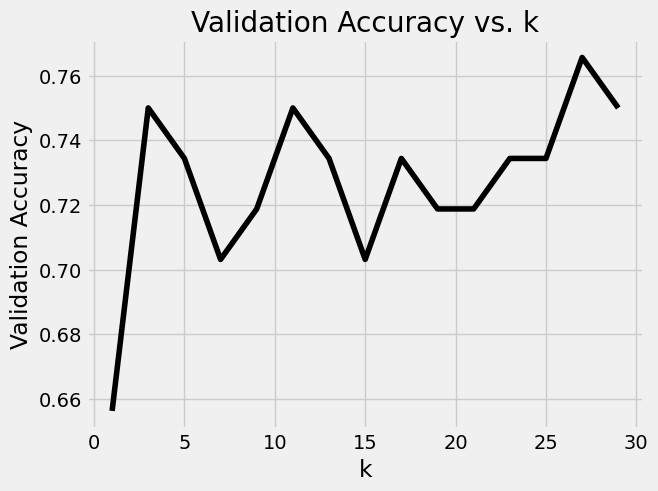

In [20]:
""" # BEGIN PROMPT
...
...

X_train = ...
y_train = ...
X_val = ...
y_val = ...
X_test = ...
y_test = ...

k_values = ...
val_accuracies = ...

for k in k_values:
    knn = ...
    ...
    y_val_pred = ...
    acc = ...
    ...

...
plt.xlabel('k')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy vs. k')
plt.show()
"""; # END PROMPT
# BEGIN SOLUTION NO PROMPT
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X_train = train[key_features]
y_train = train['Gallstone Status']
X_val = val[key_features]
y_val = val['Gallstone Status']
X_test = test[key_features]
y_test = test['Gallstone Status']

k_values = np.arange(1, 30, 2)
val_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_val_pred = knn.predict(X_val)
    acc = accuracy_score(y_val, y_val_pred)
    val_accuracies.append(acc)

plt.plot(k_values, val_accuracies, color='black')
plt.xlabel('k')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy vs. k')
plt.show()
# END SOLUTION

<!-- END QUESTION -->

---

### Task 14 📍🔎

<!-- BEGIN QUESTION -->

Using the optimal `k` value from the previous task, fit a kNN classifier to the training data, make predictions using the test set, and calculate the accuracy for the model based on the test set.

In [21]:
""" # BEGIN PROMPT
optimal_k = ...

knn = ...
...

y_pred = ...

print("Test Set Accuracy:", ...)
"""; # END PROMPT
# BEGIN SOLUTION NO PROMPT
optimal_k = 27

knn = KNeighborsClassifier(n_neighbors=optimal_k)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Test Set Accuracy:", accuracy_score(y_test, y_pred))
# END SOLUTION

Test Set Accuracy: 0.734375


<!-- END QUESTION -->

---

## APIs

* **What it is**: An API is a way for your notebook (or program) to ask another computer for data. Instead of downloading a CSV, you send a request and get data back, often in a structured format like JSON.
* **Request and response**: You send a *request* to a specific URL (the API endpoint), and the server sends back a *response* with the data. In Python, this is usually done with the [`requests` library]((https://requests.readthedocs.io/en/latest/)), for example `requests.get(url)`.
* **Parameters**: Most APIs let you customize your request by adding parameters to the URL, like specifying a date range, a city, or a search term. This is how you ask for *the specific data you want* rather than everything available.
* **API keys and access**: Many APIs require an *API key*, a unique identifier you include with your request to prove who you are and to track usage. Some are free, others have limits or require payment.
* **Why it matters for data science**: APIs give you access to live, up-to-date data (weather, stock prices, census info, social media, etc.) that would be impossible to keep current in a static CSV file. This lets your analysis reflect the real world right now.
    
```mermaid
flowchart LR
    subgraph Notebook["Direct"]
        Notebook1["Your Notebook"]
        CSV["CSV File"]
        Notebook1 -->|"Read"| CSV
    end
    
    subgraph API["API"]
        Notebook2["Your Notebook"]
        API1{{"API"}}
        Server["Remote System<br/>Database"]
        Notebook2 -->|"1. Request"| API1
        API1 -->|"2. Query"| Server
        Server -->|"3. Data"| API1
        API1 -->|"4. Response"| Notebook2
    end

    Notebook -.->|"Common Alternative"|API
```

---

### Task 15 📍🔎

<!-- BEGIN QUESTION -->

Use the (free) [Hacker News API](https://github.com/HackerNews/API) to get the IDs of the [top 10 stories](https://github.com/HackerNews/API#new-top-and-best-stories) on [Hacker News](https://news.ycombinator.com/best).

In [22]:
""" # BEGIN PROMPT
import requests
url = ...
response = ...

top_ids = ...
print(f"The IDs of the top 10 stories are: {top_ids[:10]}")
"""; # END PROMPT
# BEGIN SOLUTION NO PROMPT
import requests
url = "https://hacker-news.firebaseio.com/v0/topstories.json?print=pretty"
response = requests.get(url)

top_ids = response.json()
print(f"The IDs of the top 10 stories are: {top_ids[:10]}")
# END SOLUTION

The IDs of the top 10 stories are: [48212493, 48207660, 48214017, 48215418, 48212046, 48213651, 48174920, 48205626, 48214449, 48183167]


<!-- END QUESTION -->

---

### Task 16 📍🔎

<!-- BEGIN QUESTION -->

Get the details of the top 10 stories and store the information in a DataFrame.

In [23]:
""" # BEGIN PROMPT
def fetch_story(story_id):
    url = ...
    return ...

stories = ...
    
top10_df = ...
top10_df
"""; # END PROMPT
# BEGIN SOLUTION NO PROMPT
def fetch_story(story_id):
    url = f"https://hacker-news.firebaseio.com/v0/item/{story_id}.json"
    return requests.get(url).json()

stories = []
for sid in top_ids[:10]:
    stories.append(fetch_story(sid))
    
top10_df = pd.DataFrame(stories)
top10_df
# END SOLUTION

,by,descendants,id,kids,score,time,title,type,url,text
0,tedsanders,488,48212493,"[48214064, 48213681, 48212866, 48214003, 48214...",680,1779303930,An OpenAI model has disproved a central conjec...,story,https://openai.com/index/model-disproves-discr...,NaN
1,Timofeibu,167,48207660,"[48214112, 48214976, 48214870, 48214621, 48212...",496,1779284617,"GitHub confirms breach of 3,800 repos via mali...",story,https://www.bleepingcomputer.com/news/security...,Previous thread in sequence:<p><i>GitHub is in...
2,aurareturn,33,48214017,"[48216232, 48216251, 48216190, 48214042, 48216...",50,1779310552,Anthropic is expanding to Colossus2. Will use ...,story,https://xcancel.com/nottombrown/status/2057194...,NaN
3,rglover,16,48215418,"[48215735, 48215734, 48216106, 48216274, 48215...",68,1779317607,DOS Zone,story,https://dos.zone/,NaN
4,gregsadetsky,83,48212046,"[48213073, 48214955, 48212963, 48213700, 48214...",233,1779302036,Flipper One Tech Specs,story,https://docs.flipper.net/one/general/tech-specs,NaN
5,ki4jgt,25,48213651,"[48215376, 48213974, 48216098, 48215823, 48215...",91,1779308898,Colorado Amended SB051 (Age Verification Bill)...,story,https://legiscan.com/CO/bill/SB051/2026,NaN
6,hexagr,71,48174920,"[48212454, 48212775, 48213739, 48215885, 48212...",290,1779069878,How fast is N tokens per second really?,story,https://mikeveerman.github.io/tokenspeed/,NaN
7,kevinsimper,241,48205626,"[48207654, 48209290, 48206924, 48205897, 48206...",602,1779273302,Qwen3.7-Max: The Agent Frontier,story,https://qwen.ai/blog?id=qwen3.7,NaN
8,cdrnsf,181,48214449,"[48215154, 48215146, 48214874, 48215249, 48215...",302,1779312798,Google Declaring War on the Web,story,https://tante.cc/2026/05/20/on-google-declarin...,NaN
9,jger15,0,48183167,NaN,10,1779127453,Your Most Improbable Life,story,https://kevinkelly.substack.com/p/your-most-im...,NaN


<!-- END QUESTION -->

---

## LLMs

<a href="https://www.geeksforgeeks.org/nlp/nlp-vs-llm/"><img src="./NLP-vs-LLM.webp" alt="Venn Diagram of AI" width=400px></a>

- **What it is**: An LLM (Large Language Model) is a machine learning model trained on huge amounts of data that can understand and generate human-like responses. You interact with it by sending a *prompt* (your question or instructions) and getting back a response. Modern LLMs are often *multimodal*, meaning they can also accept images, PDFs, audio, or video as input, not just text.
- **Prompt and response**: You send a prompt to the LLM and it returns a generated response. In Python, this is usually done through an API call, for example using the `anthropic` or `openai` library to send your prompt and receive the model's reply.
- **Parameters**: Most LLMs let you control the output with parameters like `temperature` (how creative or random the response is), `max_tokens` (how long the response can be), and `model` (which version to use, such as a smaller, faster one or a larger, smarter one).
- **API keys and access**: LLMs are accessed through APIs that require an *API key* to authenticate your requests and track usage. Most providers charge based on the number of *tokens* (chunks of text or other data) sent and received, so cost scales with how much you ask and how much you get back.
- **Why it matters for data science**: LLMs let you analyze unstructured data at scale, things like summarizing documents, classifying tweets, extracting information from messy text, describing images, transcribing audio, or even generating code. This opens up data sources that traditional methods struggle with.

---

### Task 17 📍🔎

<!-- BEGIN QUESTION -->

<a href="https://openrouter.ai/"><img src="./openrouter.png" alt="OpenRouter call to action screenshot" width=400px></a>

OpenRouter is a service that gives you a single API to access many LLMs (Claude, GPT, Llama, Gemini, etc.), including some free ones.
1. Go to https://openrouter.ai and sign up for a free account.
2. Create a new API key. (You'll delete it later.)
3. Paste the key in the input box in the next code cell.

In [24]:
""" # BEGIN PROMPT
from getpass import getpass
api_key = getpass("Paste your OpenRouter API key (input is hidden): ")

"""; # END PROMPT
# BEGIN SOLUTION NO PROMPT
from getpass import getpass
api_key = getpass("Paste your OpenRouter API key (input is hidden): ")
# END SOLUTION

Paste your OpenRouter API key (input is hidden):  ········


<!-- END QUESTION -->

---

### Task 18 📍🔎

<!-- BEGIN QUESTION -->

You can access the various LLM models on OpenRouter through an API call.
1. Specify a model. (We'll try the free model `nvidia/nemotron-3-super-120b-a12b:free`)
2. Send the model a prompt.
3. Read the response form the model.

In [25]:
""" # BEGIN PROMPT
model = ...
prompt = ...
response = requests.post(
    "https://openrouter.ai/api/v1/chat/completions",
    headers={
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json",
    },
    json={
        "model": model,
        "messages": [
            {"role": "user", "content": prompt}
        ],
    },
    timeout=30,
)
response.json()
"""; # END PROMPT
# BEGIN SOLUTION NO PROMPT
model = "nvidia/nemotron-3-super-120b-a12b:free"
prompt = "In 1 sentence, explain what Pandas is?"
response = requests.post(
    "https://openrouter.ai/api/v1/chat/completions",
    headers={
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json",
    },
    json={
        "model": model,
        "messages": [
            {"role": "user", "content": prompt}
        ],
    },
    timeout=30,
)
#response.raise_for_status()
response.json()
# END SOLUTION

{'id': 'gen-1779325047-jKCGOc9TYWctzcagj4D6',
 'object': 'chat.completion',
 'created': 1779325047,
 'model': 'nvidia/nemotron-3-super-120b-a12b-20230311:free',
 'provider': 'Nvidia',
 'system_fingerprint': None,
 'choices': [{'index': 0,
   'logprobs': None,
   'finish_reason': 'stop',
   'native_finish_reason': 'stop',
   'message': {'role': 'assistant',
    'content': 'Pandas is a Python library that provides powerful, flexible data structures (like DataFrames and Series) and functions for efficient data manipulation, cleaning, and analysis.',
    'refusal': None,
    'reasoning': 'We need to answer in one sentence: Pandas is a Python library for data manipulation and analysis providing DataFrames, etc. Provide one sentence.\n\n',
    'reasoning_details': [{'type': 'reasoning.text',
      'text': 'We need to answer in one sentence: Pandas is a Python library for data manipulation and analysis providing DataFrames, etc. Provide one sentence.\n\n',
      'format': 'unknown',
      'in

<!-- END QUESTION -->

---

### Task 19 📍🔎

<!-- BEGIN QUESTION -->

Prompt the LLM to explore the `top10_df` DataFrame.

In [26]:
""" # BEGIN PROMPT
model = "nvidia/nemotron-3-super-120b-a12b:free"
df_text = top10_df.to_csv(index=False)

prompt = f'''Here is a dataset in CSV format:

{df_text}

What do you notice?'''


response = requests.post(
    "https://openrouter.ai/api/v1/chat/completions",
    headers={
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json",
    },
    json={
        "model": model,
        "messages": [
            {"role": "user", "content": prompt}
        ],
    },
    timeout=30,
)
print(response.json()["choices"][0]["message"]["content"])
"""; # END PROMPT
# BEGIN SOLUTION NO PROMPT
model = "nvidia/nemotron-3-super-120b-a12b:free"
df_text = top10_df.to_csv(index=False)

prompt = f'''Here is a dataset in CSV format:

{df_text}

What do you notice?'''


response = requests.post(
    "https://openrouter.ai/api/v1/chat/completions",
    headers={
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json",
    },
    json={
        "model": model,
        "messages": [
            {"role": "user", "content": prompt}
        ],
    },
    timeout=30,
)
#response.raise_for_status()
print(response.json()["choices"][0]["message"]["content"])
# END SOLUTION

Here are a few quick observations about the CSV snippet you posted:

| Observation | Details |
|-------------|---------|
| **Number of rows** | 9 data rows (plus the header). |
| **Column types** | Mostly what you’d expect from a Hacker News‑style dump: <br>• `by` – username (string) <br>• `descendants` – integer comment count <br>• `id` – integer post ID <br>• `kids` – string that looks like a Python‑list of child comment IDs (e.g. `"[48214064, 48213681, …]"`) <br>• `score` – integer up‑vote score <br>• `time` – Unix epoch timestamp (seconds) <br>• `title` – post title (string) <br>• `type` – always `"story"` in this slice <br>• `url` – link to the external article (string) <br>• `text` – the HN‑provided body/markdown; mostly empty (`""`) except for the `Timofeibu` row, which contains a short HTML snippet referencing a previous thread. |
| **Missing / empty values** | • `kids` is empty for the last row (`jger15,0,48183167,,10,…`) – the post has no child comments. <br>• `text` is empty

<!-- END QUESTION -->

---

## Reflection

In this activity, you reflected on the course design for MATH 108, learned about a few key Python libraries for data analysis and machine learning, and revisited two Guided Learning Activities by completing similar tasks without the `datascience` library used in MATH 108.

## Attribution

This content is licensed under the <a href="https://creativecommons.org/licenses/by-nc-sa/4.0/">Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International License (CC BY-NC-SA 4.0)</a>.

<img src="./by-nc-sa.png" width=100px>